# Distributional Evaluation

AHBA-vs-GTEx distributional checks for held-out matched parcels and optional fullfit imputed parcels.

In [22]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from src.eval_utils.eda_core import EDAConfig, prepare_pre_post_harmonization_cached
from src.eval_utils.eval_population import build_global_prediction_tables, make_prediction_eval_view, format_gene_list_name
from src.eval_utils.eval_distributional import (
    ahba_parcel_matrix,
    make_matched_distribution_frame,
    make_fullfit_imputed_distribution_frame,
    plot_ahba_distribution_panels,
)
from src.eval_utils.eval_style import set_academic_style

set_academic_style()


In [23]:
import importlib
import src.eval_utils.eval_distributional as eval_distributional
importlib.reload(eval_distributional)

from src.eval_utils.eval_distributional import (
    ahba_parcel_matrix,
    make_matched_distribution_frame,
    make_fullfit_imputed_distribution_frame,
    plot_ahba_distribution_panels,
)

## Config

In [24]:
CFG = EDAConfig(
    csv_path="data/raw/gxp_samples.csv",
    cache_root="out/loro_subject_cache_cv",
    gene_scope="allgenes",
)

MODELS = ["naive", "dlam", "plam"]
EVAL_GENE_LIST_PATH = "gtex_100hvg"
COLOR_BY = "gene"  # gene | region_group | gtex_region
MAX_MATCHED_POINTS_PER_PANEL = 12_000
MAX_IMPUTED_POINTS_PER_MODEL = 12_000
TOP_N_COLOR_GENES = 10
RANDOM_SEED = 123
FORCE_REBUILD_TABLES = False
FORCE_REBUILD_PREPOST = False

## Load Cached Tables

In [25]:
prepost = prepare_pre_post_harmonization_cached(CFG, force_rebuild=FORCE_REBUILD_PREPOST)
truth_df, pred_dfs, manifest = build_global_prediction_tables(
    CFG,
    prepost,
    models=MODELS,
    cache=True,
    force_rebuild=FORCE_REBUILD_TABLES,
)

view = make_prediction_eval_view(
    truth_df,
    pred_dfs,
    models=MODELS,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
)

genes = list(view["genes"])
gene_label = format_gene_list_name(EVAL_GENE_LIST_PATH)
print(f"rows={len(view['truth_df']):,}, genes={len(genes):,} ({gene_label}), models={view['models']}")

[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)
rows=2,869, genes=94 (GTEx 100 HVG), models=['naive', 'dlam', 'plam']


## Helpers

In [26]:
# Distributional plotting helpers live in src/eval_utils/eval_distributional.py.
# Re-run the import cell above after editing that module.


## Matched Held-Out Parcels Only

Circles are strict LORO matched parcels: AHBA at the held-out parcel/gene versus GTEx truth or model prediction at the same subject, parcel, and gene.

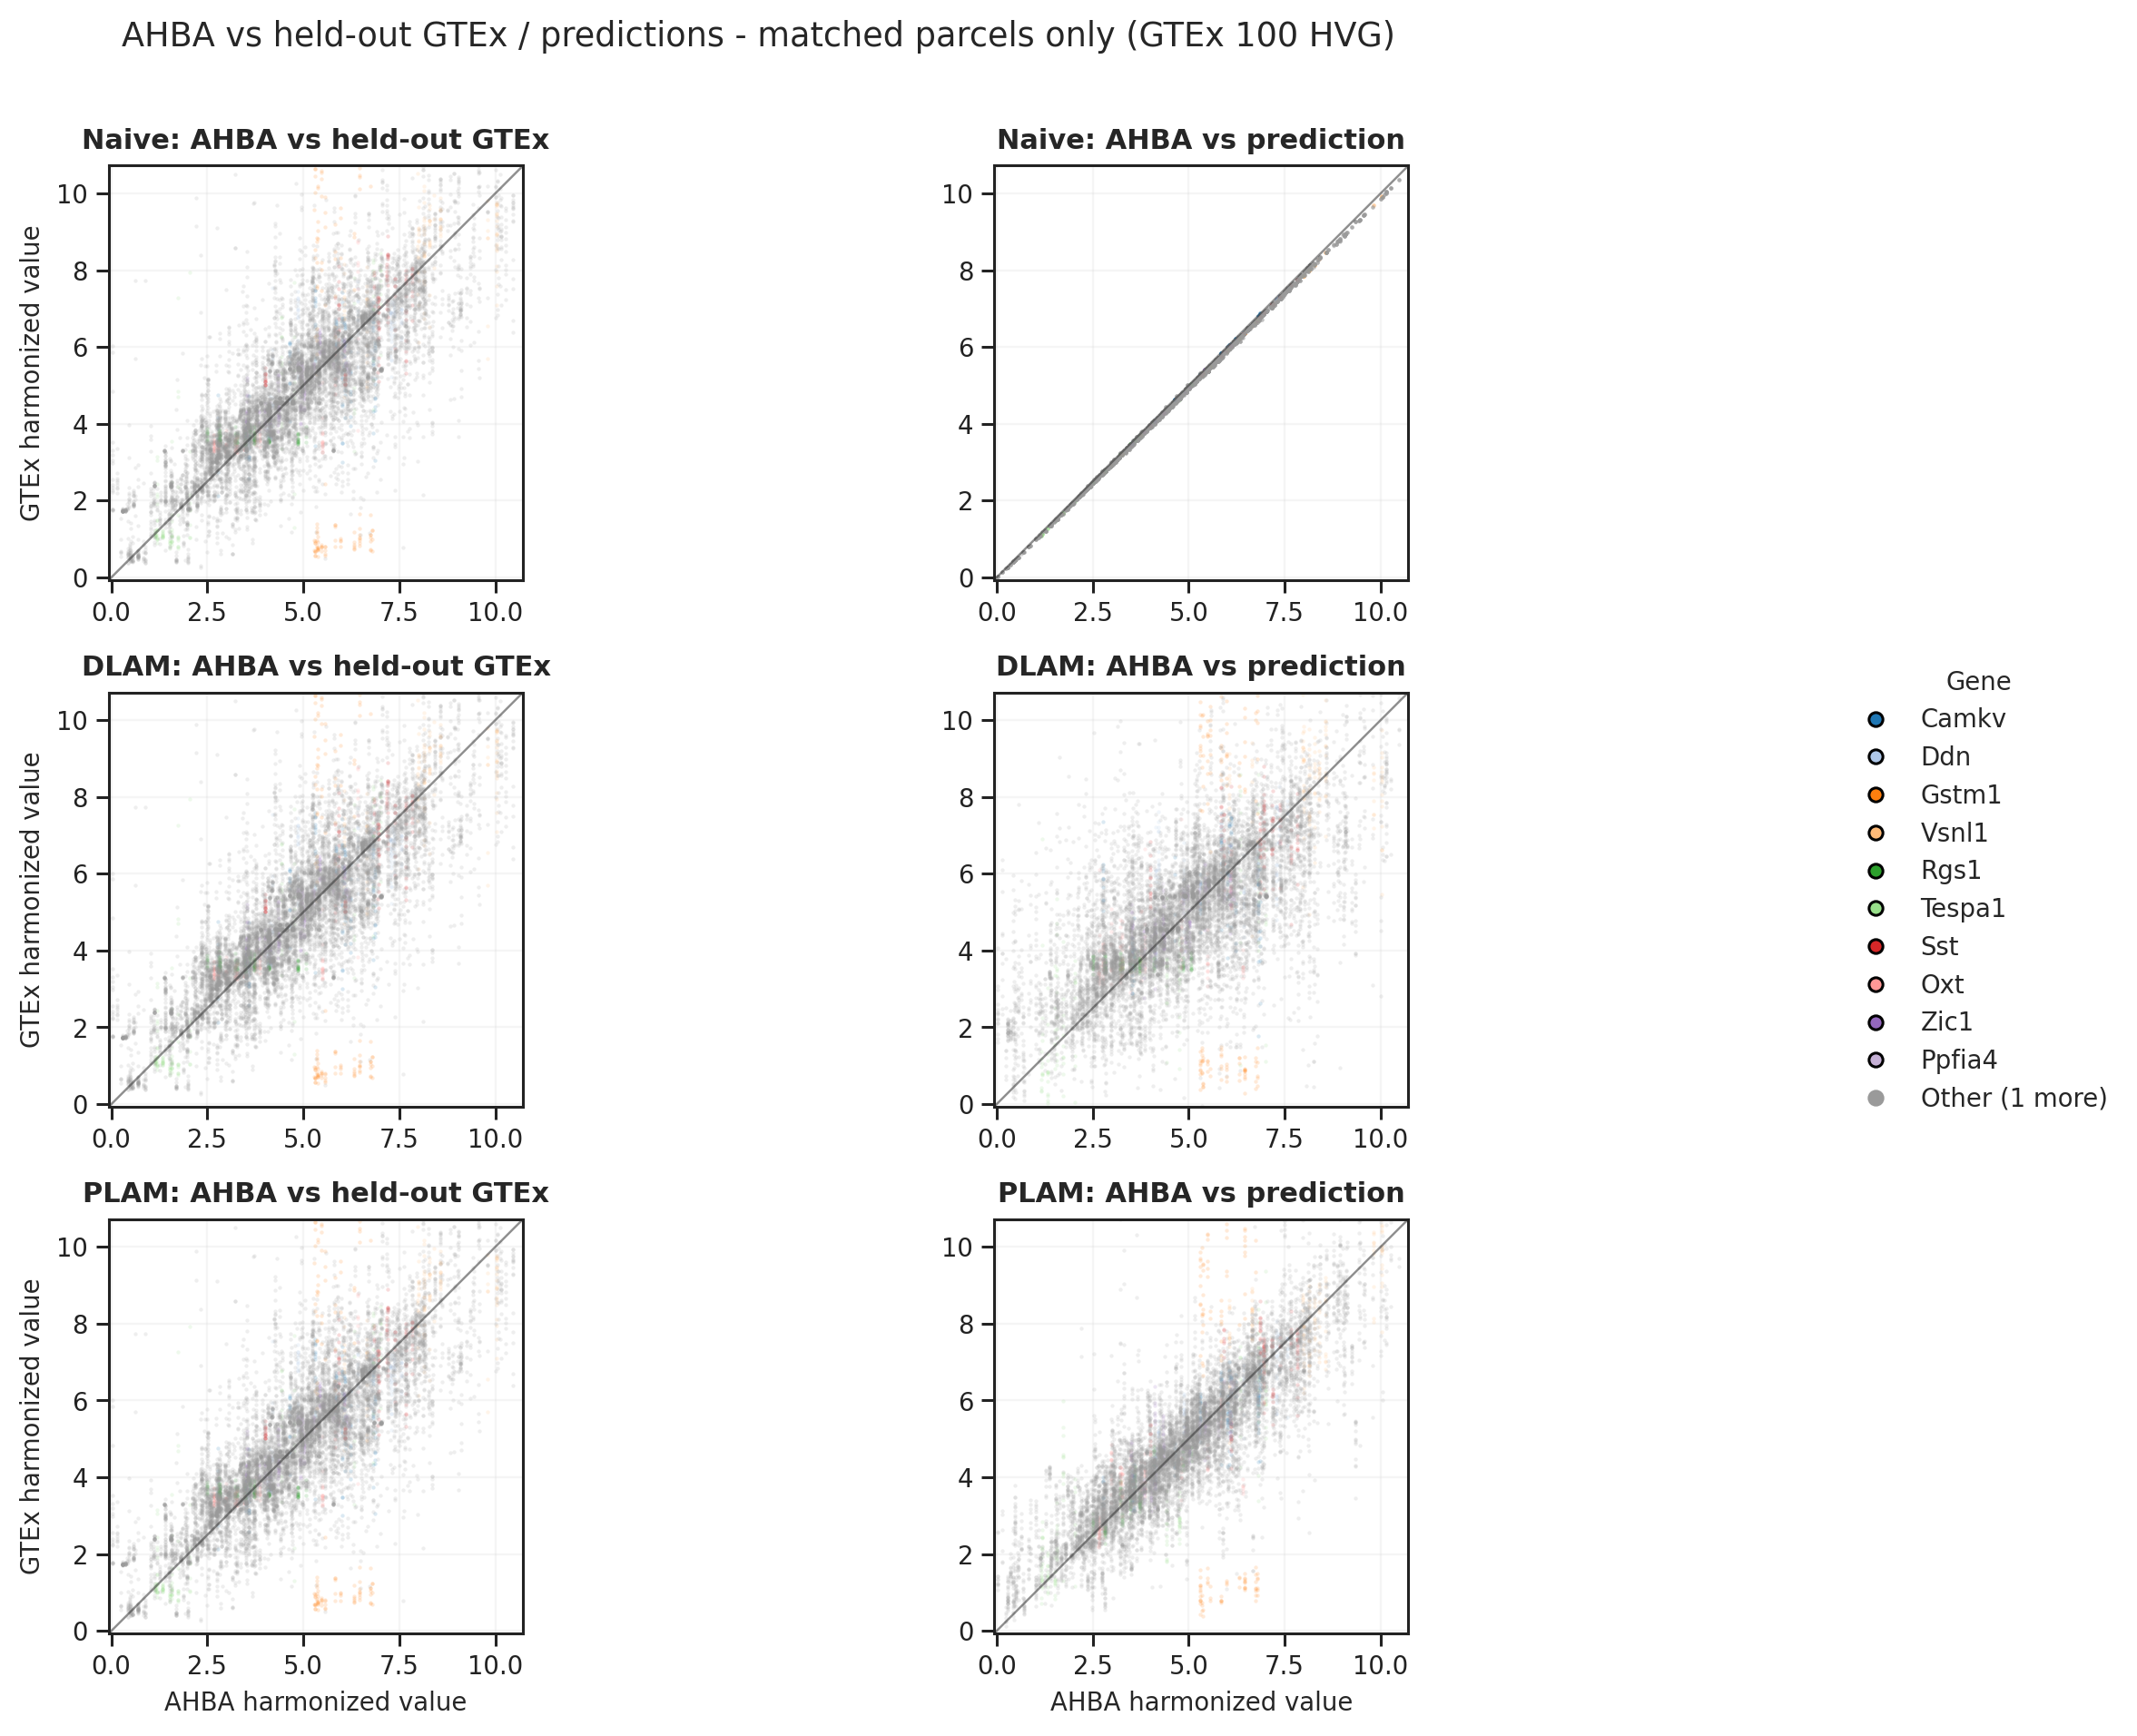

In [27]:
ahba_mat = ahba_parcel_matrix(prepost, genes, agg="mean")
matched_df = make_matched_distribution_frame(
    view,
    ahba_mat,
    color_by=COLOR_BY,
    max_points_per_panel=MAX_MATCHED_POINTS_PER_PANEL,
    seed=RANDOM_SEED,
)
fig, axes = plot_ahba_distribution_panels(
    matched_df,
    MODELS,
    color_by=COLOR_BY,
    title=f"AHBA vs held-out GTEx / predictions - matched parcels only ({gene_label})",
    include_imputed=False,
    top_n=TOP_N_COLOR_GENES,
)


## Add Fullfit Imputed Parcels

Prediction panels can overlay fullfit imputed parcels as triangles. Circles remain strict LORO matched parcels; triangles are parcels without held-out GTEx truth for that subject in the cache.

matched rows shown=48,000; imputed rows shown=36,000


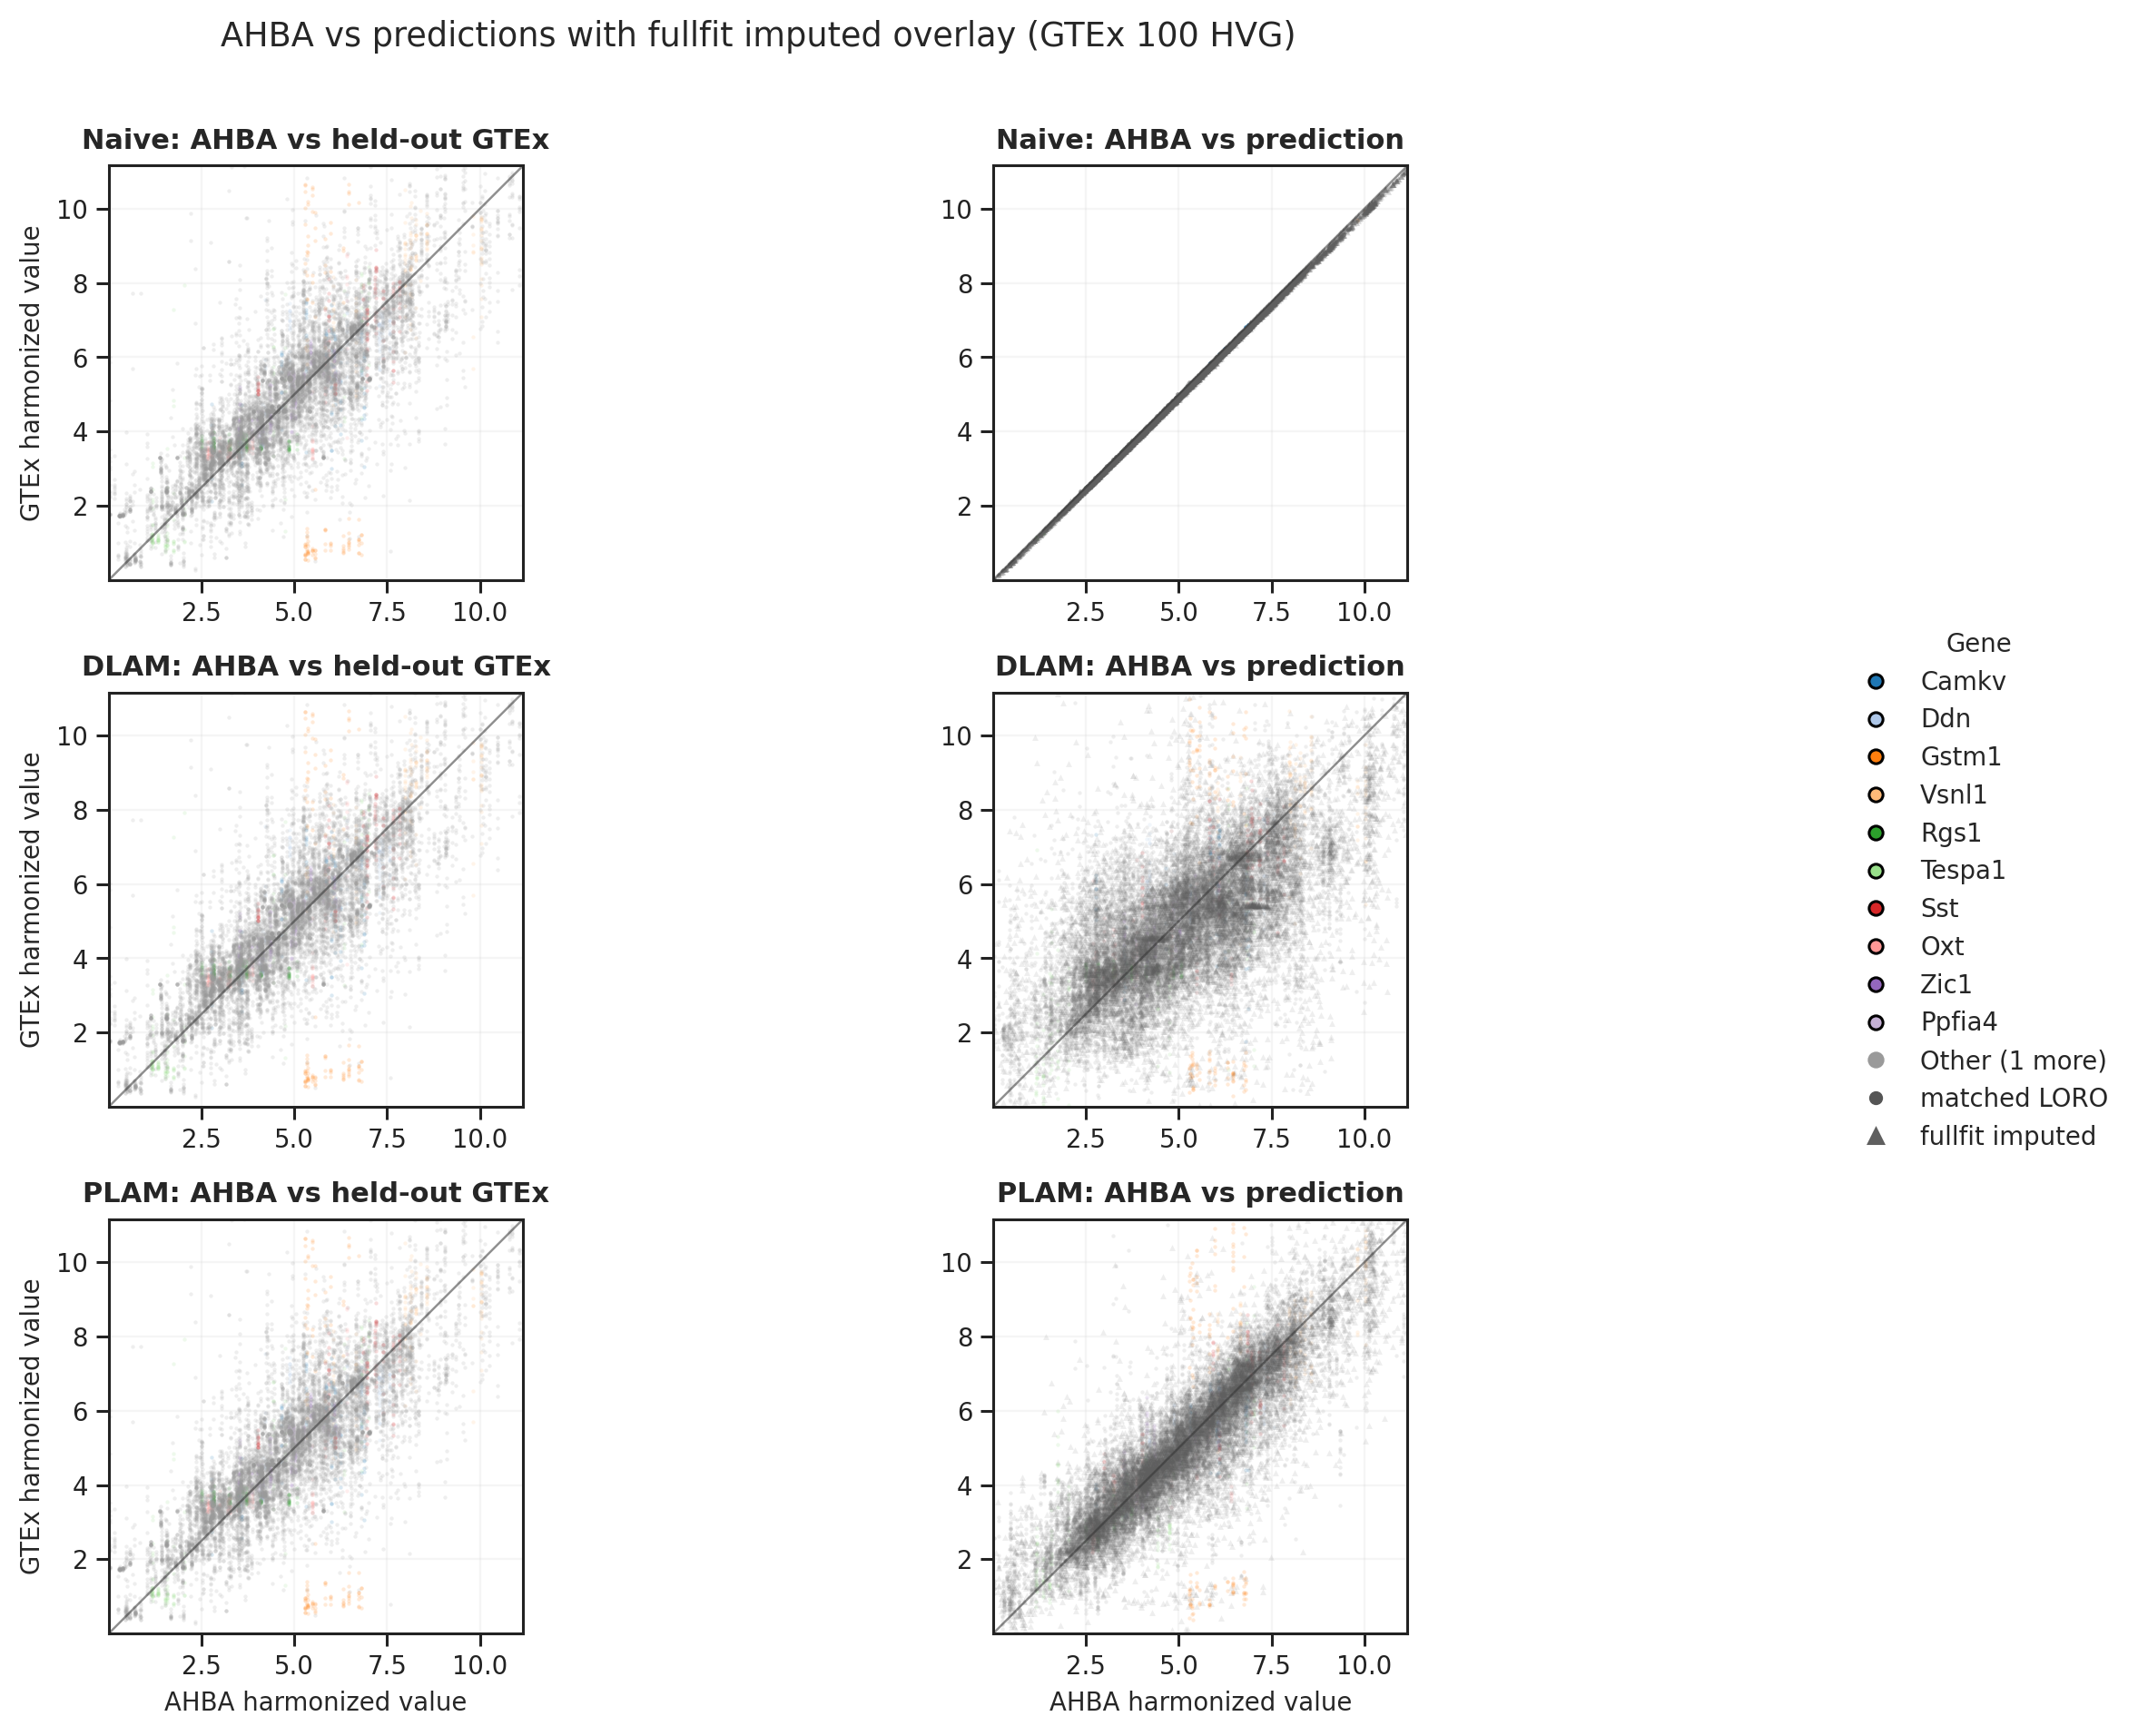

In [28]:
imputed_df = make_fullfit_imputed_distribution_frame(
    CFG,
    prepost,
    ahba_mat,
    genes,
    MODELS,
    color_by=COLOR_BY,
    max_points_per_model=MAX_IMPUTED_POINTS_PER_MODEL,
    seed=RANDOM_SEED,
)
combined_df = pd.concat([matched_df, imputed_df], ignore_index=True)
print(f"matched rows shown={len(matched_df):,}; imputed rows shown={len(imputed_df):,}")

fig, axes = plot_ahba_distribution_panels(
    combined_df,
    MODELS,
    color_by=COLOR_BY,
    title=f"AHBA vs predictions with fullfit imputed overlay ({gene_label})",
    include_imputed=True,
    top_n=TOP_N_COLOR_GENES,
)
